In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reading in files

In [2]:
bc_activity = pd.read_csv("../output/testgfp1_activity_SK_by_barcode.csv")
bc_activity = bc_activity.rename(columns = {"Unnamed: 0" : "BC", "0_y" : "AD"})
bc_activity

,BC,0_x,1,2,3,4,5,6,7,Activity,AD
0,TCCGTCTCCTG,0.587587,0.222934,0.040448,0.134129,0.000000,0.014902,0.000000,0.000000,237.122104,CAAGCTTTGTCTTTGTGTAATAATTTGTTGGGTTCTCAGAATAGAC...
1,TCTGTTGTAAC,0.413736,0.375313,0.120563,0.081555,0.005883,0.002695,0.000110,0.000144,238.096241,TTGGAACATGGTTTGGAGAATGGTGCTGCTGCTGCTTTGGATGATA...
2,TAGTTCGCCCT,0.268681,0.313838,0.252722,0.035037,0.082433,0.047289,0.000000,0.000000,342.651124,ACTTGGGAACCAGACTTTGATTCTGGTTCTCAATTTATCTTAAATT...
3,TGTCCGCTGGC,0.314635,0.307595,0.198097,0.128112,0.024464,0.015612,0.006488,0.004998,335.152026,GATATCTTTGCTGCTGTTGCTCCAGCTGCTGATCCAGATGATCCTA...
4,GGCTTCGTGAA,0.486986,0.377752,0.097760,0.021031,0.003402,0.004643,0.005513,0.002912,244.920500,TTGGCTCATGGTTTGGCTAATGGTGCTAAAGCTATGTTGGCTGCTA...
...,...,...,...,...,...,...,...,...,...,...,...
53590,CCCGAGAGCAC,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,TTGGCTCATGGTTTGGCTAATGGTGCTAAAGCTATGTTGGCTGCTA...
53591,CCTTACGAGGT,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,AAAGATAGAGATCAAGAGAATGAAGGTAATGAAGATCCAACTTGGT...
53592,ATGCAGAAATC,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,GGTGATAAAGCTGAACAAGAAGTTTCTGAAGATATCTTTGCTGCTG...
53593,CTCAAATGACG,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,GCTAATGTTAATGAATTTGGTTTGGTTAATCATCAAGCTCATCAAA...


In [3]:
bc_bin_counts = pd.read_csv("../output/testgfp1_bins_SK_by_barcode.csv")
bc_bin_counts = bc_bin_counts.rename(columns = {"Unnamed: 0" : "BC"})
bc_bin_counts["reads"] = bc_bin_counts.iloc[:, 1:].sum(axis = 1)
bc_bin_counts

,BC,0,1,2,3,4,5,6,7,reads
0,CCCAGATGAGC,11794.0,21846.0,24339.0,16657.0,20272.0,10129.0,2129.0,197.0,107363.0
1,TACCGATCAAA,879.0,319.0,395.0,1.0,193.0,0.0,1.0,0.0,1788.0
2,TCCGTCTCCTG,4579.0,1697.0,357.0,1219.0,0.0,146.0,0.0,0.0,7998.0
3,ACCGGCTACCC,561170.0,581667.0,539819.0,409021.0,101947.0,59483.0,24187.0,19958.0,2297252.0
4,TCTGTTGTAAC,15995.0,14173.0,5279.0,3677.0,232.0,131.0,5.0,6.0,39498.0
...,...,...,...,...,...,...,...,...,...,...
199571,AGTCCTCGTAG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,12.0
199572,TCCAGAGAGAA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,11.0
199573,CGGCGGTGTGC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,11.0
199574,ACGGCCATAGT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,11.0


In [4]:
bc_activity_reads = pd.merge(bc_activity, bc_bin_counts, on = "BC")
bc_activity_reads

,BC,0_x,1_x,2_x,3_x,4_x,5_x,6_x,7_x,Activity,AD,0,1_y,2_y,3_y,4_y,5_y,6_y,7_y,reads
0,TCCGTCTCCTG,0.587587,0.222934,0.040448,0.134129,0.000000,0.014902,0.000000,0.000000,237.122104,CAAGCTTTGTCTTTGTGTAATAATTTGTTGGGTTCTCAGAATAGAC...,4579.0,1697.0,357.0,1219.0,0.0,146.0,0.0,0.0,7998.0
1,TCTGTTGTAAC,0.413736,0.375313,0.120563,0.081555,0.005883,0.002695,0.000110,0.000144,238.096241,TTGGAACATGGTTTGGAGAATGGTGCTGCTGCTGCTTTGGATGATA...,15995.0,14173.0,5279.0,3677.0,232.0,131.0,5.0,6.0,39498.0
2,TAGTTCGCCCT,0.268681,0.313838,0.252722,0.035037,0.082433,0.047289,0.000000,0.000000,342.651124,ACTTGGGAACCAGACTTTGATTCTGGTTCTCAATTTATCTTAAATT...,3873.0,4419.0,4126.0,589.0,1212.0,857.0,0.0,0.0,15076.0
3,TGTCCGCTGGC,0.314635,0.307595,0.198097,0.128112,0.024464,0.015612,0.006488,0.004998,335.152026,GATATCTTTGCTGCTGTTGCTCCAGCTGCTGATCCAGATGATCCTA...,306407.0,292602.0,218496.0,145500.0,24300.0,19114.0,7411.0,5240.0,1019070.0
4,GGCTTCGTGAA,0.486986,0.377752,0.097760,0.021031,0.003402,0.004643,0.005513,0.002912,244.920500,TTGGCTCATGGTTTGGCTAATGGTGCTAAAGCTATGTTGGCTGCTA...,59645.0,45193.0,13561.0,3004.0,425.0,715.0,792.0,384.0,123719.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53590,CCCGAGAGCAC,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,TTGGCTCATGGTTTGGCTAATGGTGCTAAAGCTATGTTGGCTGCTA...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21.0,21.0
53591,CCTTACGAGGT,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,AAAGATAGAGATCAAGAGAATGAAGGTAATGAAGATCCAACTTGGT...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,11.0
53592,ATGCAGAAATC,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,GGTGATAAAGCTGAACAAGAAGTTTCTGAAGATATCTTTGCTGCTG...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,11.0
53593,CTCAAATGACG,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,GCTAATGTTAATGAATTTGGTTTGGTTAATCATCAAGCTCATCAAA...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,18.0


# How many reads per BC?

In [5]:
min(bc_activity_reads["reads"])

11.0

In [6]:
np.mean(bc_activity_reads["reads"])

11277.145647914918

In [7]:
np.median(bc_activity_reads["reads"])

39.0

In [8]:
np.percentile(bc_activity_reads["reads"], 10)

13.0

In [9]:
np.percentile(bc_activity_reads["reads"], 90)

5602.199999999997

<Axes: xlabel='reads', ylabel='Count'>

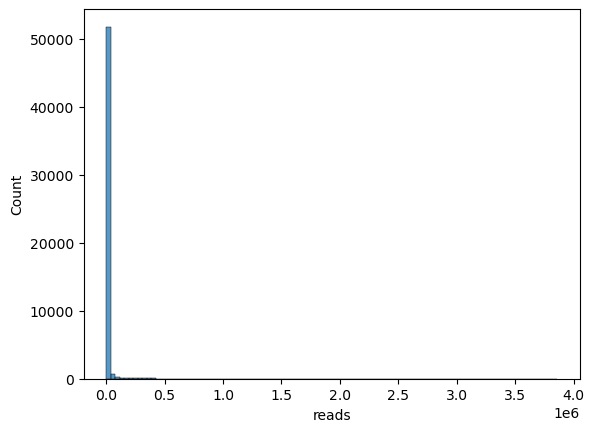

In [10]:
sns.histplot(bc_activity_reads["reads"], bins = 100)

# How many BCs per AD?

In [11]:
bc_AD_count = bc_activity_reads[["BC", "AD"]].groupby("AD").count().reset_index()
bc_AD_count

,AD,BC
0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,3
1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,4
2,AAACAAAGATCTATTCCATTGTCTCCAATTGTTCCAGAATCTTCTG...,2
3,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,2
4,AAACAAATTGTCTTGGATCCATCTAATATTGAATTGGATACTCCAC...,2
...,...,...
11382,TTTGATTCTCCAGATGTTGCTGAATCATTTGAAACTTCTCCATTGT...,1
11383,TTTGATTGGGAACCAACTGATTCTGGTTCTCAATTTATCTTAAATT...,2
11384,TTTGCTGCTGGTGCTAGGAAGAGAAGGAAGATTCATGATGATGACT...,7
11385,TTTGTTAAAGATTCTTTGCAAGATATTGGTAAATACTTTGAAATTG...,2


<Axes: xlabel='BC', ylabel='Count'>

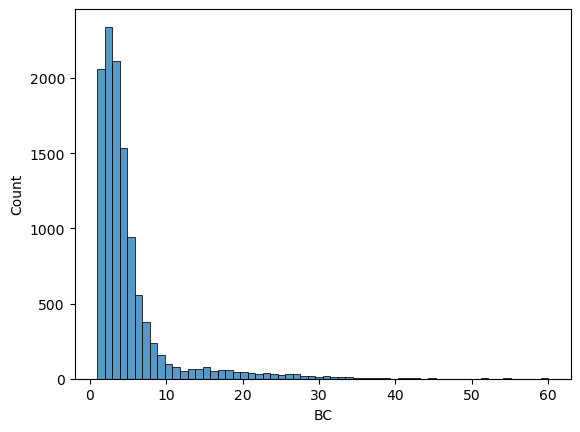

In [12]:
sns.histplot(bc_AD_count["BC"], bins = 60)

# How much variability is there in total # reads per barcode of same AD?

In [13]:
read_std = bc_activity_reads[["AD", "reads"]].groupby("AD").std().reset_index()
read_std

,AD,reads
0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,122.353314
1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,22039.508046
2,AAACAAAGATCTATTCCATTGTCTCCAATTGTTCCAGAATCTTCTG...,2.121320
3,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,3572.303459
4,AAACAAATTGTCTTGGATCCATCTAATATTGAATTGGATACTCCAC...,71.417785
...,...,...
11382,TTTGATTCTCCAGATGTTGCTGAATCATTTGAAACTTCTCCATTGT...,NaN
11383,TTTGATTGGGAACCAACTGATTCTGGTTCTCAATTTATCTTAAATT...,4413.760528
11384,TTTGCTGCTGGTGCTAGGAAGAGAAGGAAGATTCATGATGATGACT...,126.370958
11385,TTTGTTAAAGATTCTTTGCAAGATATTGGTAAATACTTTGAAATTG...,0.000000


In [14]:
read_std.sort_values(by = "reads", ascending = False).dropna().iloc[500]["AD"]

'GGTTCTCAAGATAGAGCTGAGAATACTAATTCTGGTTCTTTGAAAGATAAACAACCATGTATTGCTGCTTATGCTCATTTGGGTCCAGAAGACTTTAAGAGAGATTTGGAAGAATGTCAA'

In [15]:
test_df = bc_activity_reads[bc_activity_reads["AD"] == "GGTTCTCAAGATAGAGCTGAGAATACTAATTCTGGTTCTTTGAAAGATAAACAACCATGTATTGCTGCTTATGCTCATTTGGGTCCAGAAGACTTTAAGAGAGATTTGGAAGAATGTCAA"]
test_df

,BC,0_x,1_x,2_x,3_x,4_x,5_x,6_x,7_x,Activity,AD,0,1_y,2_y,3_y,4_y,5_y,6_y,7_y,reads
821,TGTGCCTCTTG,0.204703,0.208964,0.206513,0.154245,0.145131,0.060122,0.012358,0.007964,499.553540,GGTTCTCAAGATAGAGCTGAGAATACTAATTCTGGTTCTTTGAAAG...,48539.0,48400.0,55461.0,42654.0,35101.0,17923.0,3437.0,2033.0,253548.0
24436,CCAATAAAACA,0.084029,0.086024,0.222574,0.072052,0.247148,0.066838,0.143285,0.078050,1291.640983,GGTTCTCAAGATAGAGCTGAGAATACTAATTCTGGTTCTTTGAAAG...,1.0,1.0,3.0,1.0,3.0,1.0,2.0,1.0,13.0
29788,CACATATACTA,0.087247,0.267956,0.154065,0.000000,0.085538,0.000000,0.000000,0.405195,2769.440187,GGTTCTCAAGATAGAGCTGAGAATACTAATTCTGGTTCTTTGAAAG...,1.0,3.0,2.0,0.0,1.0,0.0,0.0,5.0,12.0
53423,CGTTTCTAGGA,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.084073,0.915927,6040.464458,GGTTCTCAAGATAGAGCTGAGAATACTAATTCTGGTTCTTTGAAAG...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,20.0,22.0


In [16]:
np.std(test_df["Activity"])

2120.086914121556

In [18]:
np.average([499, 1291, 2769, 6040], weights = [253548, 13, 12, 22])

499.62871113389457

Text(0.5, 0, 'Read standard deviation per AD')

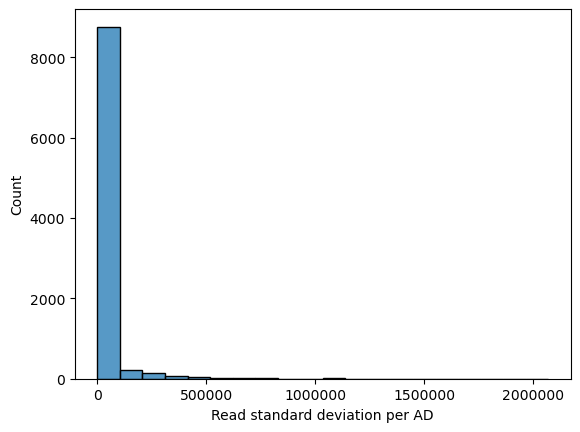

In [20]:
ax = sns.histplot(read_std["reads"], bins = 20)
ax.get_xaxis().get_major_formatter().set_scientific(False)
plt.xlabel("Read standard deviation per AD")


# How does average BC activity correspond to AD activity?

In [22]:
ad_activity = pd.read_csv("../output/testgfp1_activity_SK.csv")
ad_activity

,AD,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,Activity
0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,0.176178,0.134524,0.119446,0.118311,0.124248,0.153710,0.121450,0.052133,1106.567900
1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,0.000597,0.000336,0.031947,0.079675,0.225511,0.478369,0.169162,0.014403,1406.746740
2,AAACAAAGATCTATTCCATTGTCTCCAATTGTTCCAGAATCTTCTG...,0.031193,0.064784,0.172569,0.156685,0.197985,0.198278,0.084358,0.094148,1393.949144
3,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,0.246762,0.350440,0.222152,0.179081,0.000638,0.000341,0.000181,0.000405,283.112716
4,AAACAAATTGTCTTGGATCCATCTAATATTGAATTGGATACTCCAC...,0.054550,0.031471,0.027943,0.022142,0.064118,0.071918,0.191236,0.536623,4090.212610
...,...,...,...,...,...,...,...,...,...,...
12265,TTGGCTCATGGTTTGGCTAATGGTGCTAAAGAAATGTTGGATGATA...,0.000000,0.000000,0.173655,0.258006,0.199230,0.000000,0.084888,0.284221,2363.519868
12266,AAAGATTTGGAAGAATGTCAAAGATTGGATCCATCTGATGGTACTA...,0.000000,0.000000,0.000000,0.059126,0.159799,0.237767,0.369618,0.173690,2539.072949
12267,GAAGATCCAACTTGGTTTGATTCTGGTTCTCAATTTATCTTAAATT...,0.000000,0.000000,0.000000,0.217597,0.151224,0.363474,0.171823,0.095882,1773.116090
12268,TTTATTGATACTAATCCAAATAATTTGAATGAGAAATTGAGAAATC...,0.000000,0.000000,0.000000,0.142217,0.247091,0.329943,0.280750,0.000000,1438.178123


In [23]:
bc_aggreg_activity = bc_activity[["AD", "Activity"]].groupby("AD").agg(np.mean).reset_index()
bc_aggreg_activity

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_34599/3541275901.py:1: FutureWarning: The provided callable <function mean at 0x10a02bac0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  bc_aggreg_activity = bc_activity[["AD", "Activity"]].groupby("AD").agg(np.mean).reset_index()


,AD,Activity
0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,2010.779567
1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,2543.869006
2,AAACAAAGATCTATTCCATTGTCTCCAATTGTTCCAGAATCTTCTG...,864.070396
3,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,538.983531
4,AAACAAATTGTCTTGGATCCATCTAATATTGAATTGGATACTCCAC...,3172.583658
...,...,...
11382,TTTGATTCTCCAGATGTTGCTGAATCATTTGAAACTTCTCCATTGT...,4552.652755
11383,TTTGATTGGGAACCAACTGATTCTGGTTCTCAATTTATCTTAAATT...,2658.444606
11384,TTTGCTGCTGGTGCTAGGAAGAGAAGGAAGATTCATGATGATGACT...,2284.162544
11385,TTTGTTAAAGATTCTTTGCAAGATATTGGTAAATACTTTGAAATTG...,1784.216468


In [24]:
AD_merged = pd.merge(ad_activity, bc_aggreg_activity, on = "AD", suffixes=("_AD", "_BC_avg"))
AD_merged

,AD,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,Activity_AD,Activity_BC_avg
0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,0.176178,0.134524,0.119446,0.118311,0.124248,0.153710,0.121450,0.052133,1106.567900,2010.779567
1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,0.000597,0.000336,0.031947,0.079675,0.225511,0.478369,0.169162,0.014403,1406.746740,2543.869006
2,AAACAAAGATCTATTCCATTGTCTCCAATTGTTCCAGAATCTTCTG...,0.031193,0.064784,0.172569,0.156685,0.197985,0.198278,0.084358,0.094148,1393.949144,864.070396
3,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,0.246762,0.350440,0.222152,0.179081,0.000638,0.000341,0.000181,0.000405,283.112716,538.983531
4,AAACAAATTGTCTTGGATCCATCTAATATTGAATTGGATACTCCAC...,0.054550,0.031471,0.027943,0.022142,0.064118,0.071918,0.191236,0.536623,4090.212610,3172.583658
...,...,...,...,...,...,...,...,...,...,...,...
11382,TTGGAACCAACTGATAATACTAATTTGGAATTGGATAATACTGATG...,0.000000,0.000000,0.012620,0.006250,0.000000,0.011600,0.129551,0.839979,5698.559142,5818.189124
11383,AAAGATTTGGAAGAATGTCAAAGATTGGATCCATCTGATGGTACTA...,0.000000,0.000000,0.000000,0.059126,0.159799,0.237767,0.369618,0.173690,2539.072949,2765.211859
11384,GAAGATCCAACTTGGTTTGATTCTGGTTCTCAATTTATCTTAAATT...,0.000000,0.000000,0.000000,0.217597,0.151224,0.363474,0.171823,0.095882,1773.116090,1461.367216
11385,TTTATTGATACTAATCCAAATAATTTGAATGAGAAATTGAGAAATC...,0.000000,0.000000,0.000000,0.142217,0.247091,0.329943,0.280750,0.000000,1438.178123,1442.683574


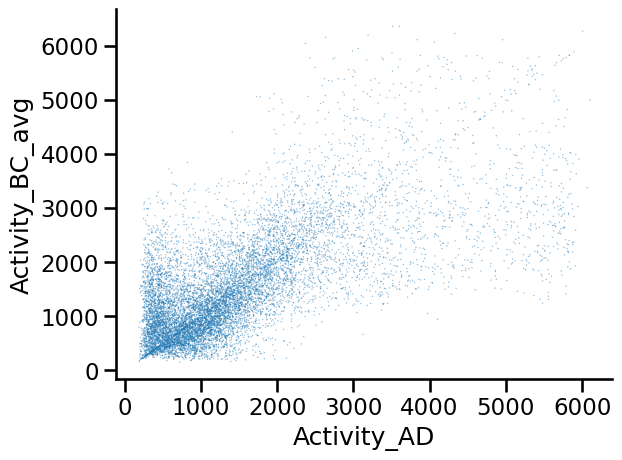

In [25]:
sns.set_context('talk')
sns.scatterplot(data = AD_merged, x = "Activity_AD", y = "Activity_BC_avg", s = 1, edgecolor = 'none', alpha = 0.5)
sns.despine()

In [26]:
bc_aggreg_error = bc_activity[["AD", "Activity"]].groupby("AD").agg(np.std).reset_index()
bc_aggreg_error

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_34599/747091034.py:1: FutureWarning: The provided callable <function std at 0x10a02bbe0> is currently using DataFrameGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  bc_aggreg_error = bc_activity[["AD", "Activity"]].groupby("AD").agg(np.std).reset_index()


,AD,Activity
0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,2082.150650
1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,1872.079725
2,AAACAAAGATCTATTCCATTGTCTCCAATTGTTCCAGAATCTTCTG...,217.073053
3,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,369.847855
4,AAACAAATTGTCTTGGATCCATCTAATATTGAATTGGATACTCCAC...,2599.372371
...,...,...
11382,TTTGATTCTCCAGATGTTGCTGAATCATTTGAAACTTCTCCATTGT...,NaN
11383,TTTGATTGGGAACCAACTGATTCTGGTTCTCAATTTATCTTAAATT...,2516.165528
11384,TTTGCTGCTGGTGCTAGGAAGAGAAGGAAGATTCATGATGATGACT...,1777.750662
11385,TTTGTTAAAGATTCTTTGCAAGATATTGGTAAATACTTTGAAATTG...,1857.022769


In [27]:
bc_aggreg_error.dropna().sort_values(by = "Activity", ascending = False)["AD"].iloc[0]

'ATTGCTGCTTATGCTCATTTGGGTCCAGCTGACTTTAAGAGAGATTTGGCTGCTTGTCAGAAGATTGTCTTGGCTCCATCTAATATTGCTTTGGCTACTCCACCAGCATTTAGATTGTCT'

In [28]:
bc_activity[bc_activity["AD"] == "ATTGCTGCTTATGCTCATTTGGGTCCAGCTGACTTTAAGAGAGATTTGGCTGCTTGTCAGAAGATTGTCTTGGCTCCATCTAATATTGCTTTGGCTACTCCACCAGCATTTAGATTGTCT"]

,BC,0_x,1,2,3,4,5,6,7,Activity,AD
15767,TGCCAGGTGTG,0.153179,0.313634,0.270493,0.262693,0.0,0.0,0.0,0.0,313.109546,ATTGCTGCTTATGCTCATTTGGGTCCAGCTGACTTTAAGAGAGATT...
53568,AGACAGATTGC,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.0,6357.000000,ATTGCTGCTTATGCTCATTTGGGTCCAGCTGACTTTAAGAGAGATT...


# How much error?

Text(0.5, 0, 'Error')

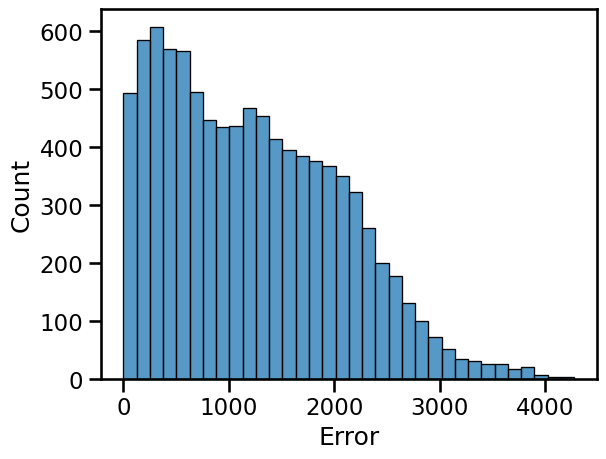

In [29]:
sns.histplot(bc_aggreg_error["Activity"])
plt.xlabel("Error")

In [31]:
bc_aggreg_error = bc_aggreg_error.rename(columns = {"Activity" : "bc_standard_dev"})
bc_aggreg_error

,AD,bc_standard_dev
0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,2082.150650
1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,1872.079725
2,AAACAAAGATCTATTCCATTGTCTCCAATTGTTCCAGAATCTTCTG...,217.073053
3,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,369.847855
4,AAACAAATTGTCTTGGATCCATCTAATATTGAATTGGATACTCCAC...,2599.372371
...,...,...
11382,TTTGATTCTCCAGATGTTGCTGAATCATTTGAAACTTCTCCATTGT...,NaN
11383,TTTGATTGGGAACCAACTGATTCTGGTTCTCAATTTATCTTAAATT...,2516.165528
11384,TTTGCTGCTGGTGCTAGGAAGAGAAGGAAGATTCATGATGATGACT...,1777.750662
11385,TTTGTTAAAGATTCTTTGCAAGATATTGGTAAATACTTTGAAATTG...,1857.022769


In [33]:
ad_activity

,AD,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,Activity
0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,0.176178,0.134524,0.119446,0.118311,0.124248,0.153710,0.121450,0.052133,1106.567900
1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,0.000597,0.000336,0.031947,0.079675,0.225511,0.478369,0.169162,0.014403,1406.746740
2,AAACAAAGATCTATTCCATTGTCTCCAATTGTTCCAGAATCTTCTG...,0.031193,0.064784,0.172569,0.156685,0.197985,0.198278,0.084358,0.094148,1393.949144
3,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,0.246762,0.350440,0.222152,0.179081,0.000638,0.000341,0.000181,0.000405,283.112716
4,AAACAAATTGTCTTGGATCCATCTAATATTGAATTGGATACTCCAC...,0.054550,0.031471,0.027943,0.022142,0.064118,0.071918,0.191236,0.536623,4090.212610
...,...,...,...,...,...,...,...,...,...,...
12265,TTGGCTCATGGTTTGGCTAATGGTGCTAAAGAAATGTTGGATGATA...,0.000000,0.000000,0.173655,0.258006,0.199230,0.000000,0.084888,0.284221,2363.519868
12266,AAAGATTTGGAAGAATGTCAAAGATTGGATCCATCTGATGGTACTA...,0.000000,0.000000,0.000000,0.059126,0.159799,0.237767,0.369618,0.173690,2539.072949
12267,GAAGATCCAACTTGGTTTGATTCTGGTTCTCAATTTATCTTAAATT...,0.000000,0.000000,0.000000,0.217597,0.151224,0.363474,0.171823,0.095882,1773.116090
12268,TTTATTGATACTAATCCAAATAATTTGAATGAGAAATTGAGAAATC...,0.000000,0.000000,0.000000,0.142217,0.247091,0.329943,0.280750,0.000000,1438.178123


In [36]:
ad_activity_with_erorr = pd.merge(ad_activity, bc_aggreg_error, on = "AD", how = 'left')
ad_activity_with_erorr

,AD,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,Activity,bc_standard_dev
0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,0.176178,0.134524,0.119446,0.118311,0.124248,0.153710,0.121450,0.052133,1106.567900,2082.150650
1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,0.000597,0.000336,0.031947,0.079675,0.225511,0.478369,0.169162,0.014403,1406.746740,1872.079725
2,AAACAAAGATCTATTCCATTGTCTCCAATTGTTCCAGAATCTTCTG...,0.031193,0.064784,0.172569,0.156685,0.197985,0.198278,0.084358,0.094148,1393.949144,217.073053
3,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,0.246762,0.350440,0.222152,0.179081,0.000638,0.000341,0.000181,0.000405,283.112716,369.847855
4,AAACAAATTGTCTTGGATCCATCTAATATTGAATTGGATACTCCAC...,0.054550,0.031471,0.027943,0.022142,0.064118,0.071918,0.191236,0.536623,4090.212610,2599.372371
...,...,...,...,...,...,...,...,...,...,...,...
12265,TTGGCTCATGGTTTGGCTAATGGTGCTAAAGAAATGTTGGATGATA...,0.000000,0.000000,0.173655,0.258006,0.199230,0.000000,0.084888,0.284221,2363.519868,NaN
12266,AAAGATTTGGAAGAATGTCAAAGATTGGATCCATCTGATGGTACTA...,0.000000,0.000000,0.000000,0.059126,0.159799,0.237767,0.369618,0.173690,2539.072949,NaN
12267,GAAGATCCAACTTGGTTTGATTCTGGTTCTCAATTTATCTTAAATT...,0.000000,0.000000,0.000000,0.217597,0.151224,0.363474,0.171823,0.095882,1773.116090,NaN
12268,TTTATTGATACTAATCCAAATAATTTGAATGAGAAATTGAGAAATC...,0.000000,0.000000,0.000000,0.142217,0.247091,0.329943,0.280750,0.000000,1438.178123,NaN


# Activity measurements vs standard deviation?

In [129]:
min(bc_activity_reads["reads"])

11.0

In [130]:
bc_activity_reads

,BC,0_x,1_x,2_x,3_x,4_x,5_x,6_x,7_x,Activity,AD,0,1_y,2_y,3_y,4_y,5_y,6_y,7_y,reads
0,TCCGTCTCCTG,0.587587,0.222934,0.040448,0.134129,0.000000,0.014902,0.000000,0.000000,237.122104,CAAGCTTTGTCTTTGTGTAATAATTTGTTGGGTTCTCAGAATAGAC...,4579.0,1697.0,357.0,1219.0,0.0,146.0,0.0,0.0,7998.0
1,TCTGTTGTAAC,0.413736,0.375313,0.120563,0.081555,0.005883,0.002695,0.000110,0.000144,238.096241,TTGGAACATGGTTTGGAGAATGGTGCTGCTGCTGCTTTGGATGATA...,15995.0,14173.0,5279.0,3677.0,232.0,131.0,5.0,6.0,39498.0
2,TAGTTCGCCCT,0.268681,0.313838,0.252722,0.035037,0.082433,0.047289,0.000000,0.000000,342.651124,ACTTGGGAACCAGACTTTGATTCTGGTTCTCAATTTATCTTAAATT...,3873.0,4419.0,4126.0,589.0,1212.0,857.0,0.0,0.0,15076.0
3,TGTCCGCTGGC,0.314635,0.307595,0.198097,0.128112,0.024464,0.015612,0.006488,0.004998,335.152026,GATATCTTTGCTGCTGTTGCTCCAGCTGCTGATCCAGATGATCCTA...,306407.0,292602.0,218496.0,145500.0,24300.0,19114.0,7411.0,5240.0,1019070.0
4,GGCTTCGTGAA,0.486986,0.377752,0.097760,0.021031,0.003402,0.004643,0.005513,0.002912,244.920500,TTGGCTCATGGTTTGGCTAATGGTGCTAAAGCTATGTTGGCTGCTA...,59645.0,45193.0,13561.0,3004.0,425.0,715.0,792.0,384.0,123719.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53590,CCCGAGAGCAC,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,TTGGCTCATGGTTTGGCTAATGGTGCTAAAGCTATGTTGGCTGCTA...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21.0,21.0
53591,CCTTACGAGGT,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,AAAGATAGAGATCAAGAGAATGAAGGTAATGAAGATCCAACTTGGT...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,11.0
53592,ATGCAGAAATC,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,GGTGATAAAGCTGAACAAGAAGTTTCTGAAGATATCTTTGCTGCTG...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,11.0
53593,CTCAAATGACG,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,GCTAATGTTAATGAATTTGGTTTGGTTAATCATCAAGCTCATCAAA...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,18.0


Text(0.5, 0, 'Reads per BC')

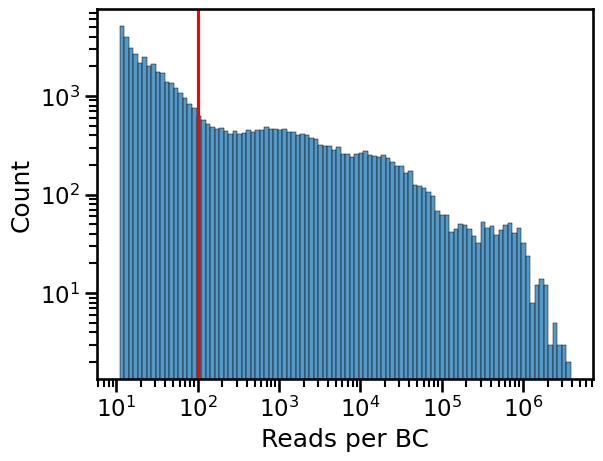

In [184]:
ax = sns.histplot(bc_activity_reads["reads"], bins = 100, log_scale=True)
ax.set_yscale('log')

plt.axvline(100, color = 'red')
plt.xlabel("Reads per BC")

# Maybe I should filter to > 60 reads per BC

In [185]:
sns.histplot([bc_activity_reads]["reads"], bins = 100, log_scale=True)
plt.axvline(100 ** 1.15, color = 'red')
plt.xlim(100**1.15, max(bc_activity_reads["reads"]))

<>:1: SyntaxWarning: list indices must be integers or slices, not str; perhaps you missed a comma?
<>:1: SyntaxWarning: list indices must be integers or slices, not str; perhaps you missed a comma?
/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_34599/3889230575.py:1: SyntaxWarning: list indices must be integers or slices, not str; perhaps you missed a comma?
  sns.histplot([bc_activity_reads]["reads"], bins = 100, log_scale=True)
/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_34599/3889230575.py:1: SyntaxWarning: list indices must be integers or slices, not str; perhaps you missed a comma?
  sns.histplot([bc_activity_reads]["reads"], bins = 100, log_scale=True)
/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_34599/3889230575.py:1: SyntaxWarning: list indices must be integers or slices, not str; perhaps you missed a comma?
  sns.histplot([bc_activity_reads]["reads"], bins = 100, log_scale=True)


TypeError: list indices must be integers or slices, not str

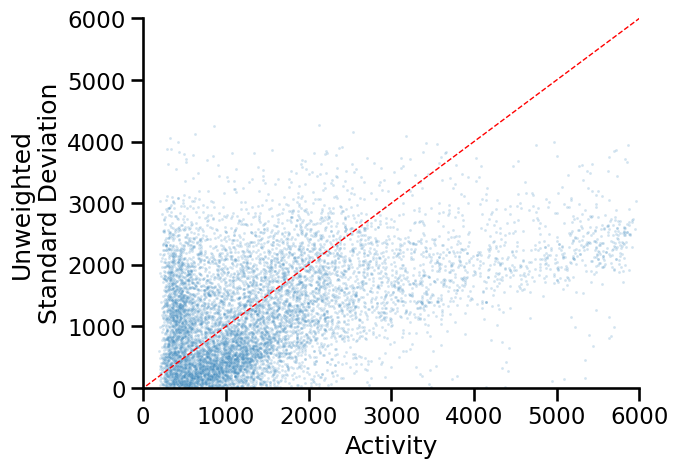

In [186]:
sns.scatterplot(data = ad_activity_with_erorr, x = "Activity", y = "bc_standard_dev", alpha = 0.2, s = 4)
xlims = plt.gca().get_xlim()
plt.plot(xlims, xlims, color='red', linestyle='--', linewidth=1)
plt.xlim(0, 6000)
plt.ylim(0, 6000)
plt.ylabel("Unweighted\nStandard Deviation")
sns.despine()
plt.show()


# Weighted standard deviation?

In [187]:
bc_activity

,BC,0_x,1,2,3,4,5,6,7,Activity,AD
0,TCCGTCTCCTG,0.587587,0.222934,0.040448,0.134129,0.000000,0.014902,0.000000,0.000000,237.122104,CAAGCTTTGTCTTTGTGTAATAATTTGTTGGGTTCTCAGAATAGAC...
1,TCTGTTGTAAC,0.413736,0.375313,0.120563,0.081555,0.005883,0.002695,0.000110,0.000144,238.096241,TTGGAACATGGTTTGGAGAATGGTGCTGCTGCTGCTTTGGATGATA...
2,TAGTTCGCCCT,0.268681,0.313838,0.252722,0.035037,0.082433,0.047289,0.000000,0.000000,342.651124,ACTTGGGAACCAGACTTTGATTCTGGTTCTCAATTTATCTTAAATT...
3,TGTCCGCTGGC,0.314635,0.307595,0.198097,0.128112,0.024464,0.015612,0.006488,0.004998,335.152026,GATATCTTTGCTGCTGTTGCTCCAGCTGCTGATCCAGATGATCCTA...
4,GGCTTCGTGAA,0.486986,0.377752,0.097760,0.021031,0.003402,0.004643,0.005513,0.002912,244.920500,TTGGCTCATGGTTTGGCTAATGGTGCTAAAGCTATGTTGGCTGCTA...
...,...,...,...,...,...,...,...,...,...,...,...
53590,CCCGAGAGCAC,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,TTGGCTCATGGTTTGGCTAATGGTGCTAAAGCTATGTTGGCTGCTA...
53591,CCTTACGAGGT,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,AAAGATAGAGATCAAGAGAATGAAGGTAATGAAGATCCAACTTGGT...
53592,ATGCAGAAATC,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,GGTGATAAAGCTGAACAAGAAGTTTCTGAAGATATCTTTGCTGCTG...
53593,CTCAAATGACG,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,GCTAATGTTAATGAATTTGGTTTGGTTAATCATCAAGCTCATCAAA...


In [188]:
def weighted_std(values, weights):
    """
    Calculates the weighted standard deviation.

    Args:
        values (np.ndarray): Array of values.
        weights (np.ndarray): Array of weights corresponding to the values.

    Returns:
        float: The weighted standard deviation.
    """
    average = np.average(values, weights=weights)
    variance = np.average((values - average)**2, weights=weights)
    return np.sqrt(variance)



In [189]:
weighted_std_by_AD = bc_activity_reads[["AD", "Activity", "reads"]].groupby("AD").apply(
    lambda sf: weighted_std(sf["Activity"], sf["reads"])
)
weighted_std_by_AD = pd.DataFrame(weighted_std_by_AD).reset_index()
weighted_std_by_AD = weighted_std_by_AD.rename(columns = {0 : "weighted_standard_dev"})
weighted_std_by_AD

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_34599/3669827740.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_std_by_AD = bc_activity_reads[["AD", "Activity", "reads"]].groupby("AD").apply(


,AD,weighted_standard_dev
0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,1083.892916
1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,111.075921
2,AAACAAAGATCTATTCCATTGTCTCCAATTGTTCCAGAATCTTCTG...,152.773383
3,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,25.401184
4,AAACAAATTGTCTTGGATCCATCTAATATTGAATTGGATACTCCAC...,1318.801372
...,...,...
11382,TTTGATTCTCCAGATGTTGCTGAATCATTTGAAACTTCTCCATTGT...,0.000000
11383,TTTGATTGGGAACCAACTGATTCTGGTTCTCAATTTATCTTAAATT...,302.142160
11384,TTTGCTGCTGGTGCTAGGAAGAGAAGGAAGATTCATGATGATGACT...,1077.121072
11385,TTTGTTAAAGATTCTTTGCAAGATATTGGTAAATACTTTGAAATTG...,1313.113393


In [190]:
ad_activity_with_both_errors = pd.merge(ad_activity_with_erorr, weighted_std_by_AD)
ad_activity_with_both_errors

,AD,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,Activity,bc_standard_dev,weighted_standard_dev
0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,0.176178,0.134524,0.119446,0.118311,0.124248,0.153710,0.121450,0.052133,1106.567900,2082.150650,1083.892916
1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,0.000597,0.000336,0.031947,0.079675,0.225511,0.478369,0.169162,0.014403,1406.746740,1872.079725,111.075921
2,AAACAAAGATCTATTCCATTGTCTCCAATTGTTCCAGAATCTTCTG...,0.031193,0.064784,0.172569,0.156685,0.197985,0.198278,0.084358,0.094148,1393.949144,217.073053,152.773383
3,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,0.246762,0.350440,0.222152,0.179081,0.000638,0.000341,0.000181,0.000405,283.112716,369.847855,25.401184
4,AAACAAATTGTCTTGGATCCATCTAATATTGAATTGGATACTCCAC...,0.054550,0.031471,0.027943,0.022142,0.064118,0.071918,0.191236,0.536623,4090.212610,2599.372371,1318.801372
...,...,...,...,...,...,...,...,...,...,...,...,...
11382,TTGGAACCAACTGATAATACTAATTTGGAATTGGATAATACTGATG...,0.000000,0.000000,0.012620,0.006250,0.000000,0.011600,0.129551,0.839979,5698.559142,NaN,0.000000
11383,AAAGATTTGGAAGAATGTCAAAGATTGGATCCATCTGATGGTACTA...,0.000000,0.000000,0.000000,0.059126,0.159799,0.237767,0.369618,0.173690,2539.072949,NaN,0.000000
11384,GAAGATCCAACTTGGTTTGATTCTGGTTCTCAATTTATCTTAAATT...,0.000000,0.000000,0.000000,0.217597,0.151224,0.363474,0.171823,0.095882,1773.116090,NaN,0.000000
11385,TTTATTGATACTAATCCAAATAATTTGAATGAGAAATTGAGAAATC...,0.000000,0.000000,0.000000,0.142217,0.247091,0.329943,0.280750,0.000000,1438.178123,NaN,0.000000


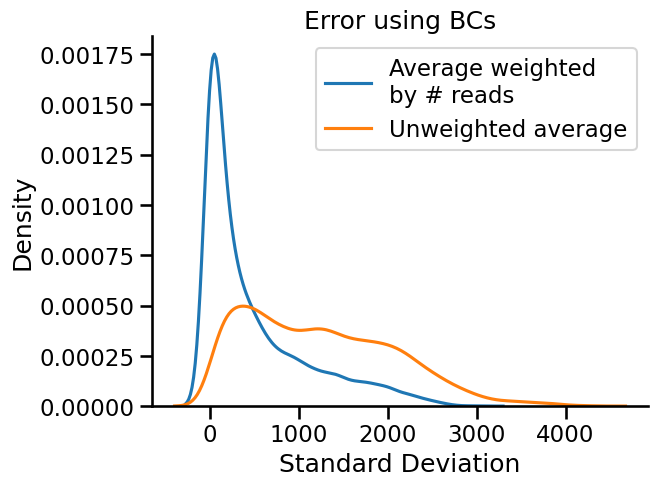

In [191]:
sns.kdeplot(data = ad_activity_with_both_errors, x = "weighted_standard_dev", label = "Average weighted\nby # reads")
sns.kdeplot(data = ad_activity_with_both_errors, x = "bc_standard_dev", label = "Unweighted average")
plt.legend()
plt.xlabel("Standard Deviation")
plt.title("Error using BCs")
sns.despine()

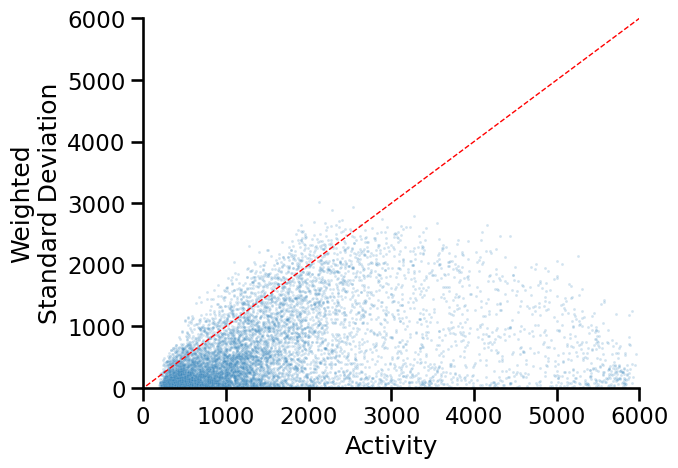

In [192]:
sns.scatterplot(data = ad_activity_with_both_errors, x = "Activity", y = "weighted_standard_dev", alpha = 0.2, s = 4)
xlims = plt.gca().get_xlim()
plt.plot(xlims, xlims, color='red', linestyle='--', linewidth=1)
plt.xlim(0, 6000)
plt.ylim(0, 6000)
sns.despine()
plt.ylabel("Weighted\nStandard Deviation")
plt.show()


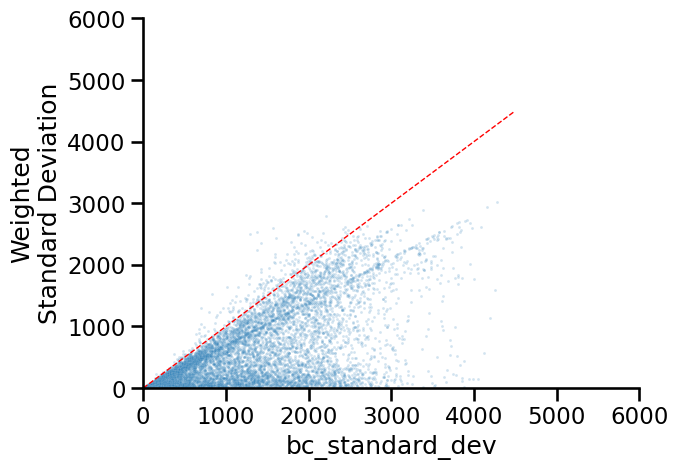

In [193]:
sns.scatterplot(data = ad_activity_with_both_errors, x = "bc_standard_dev", y = "weighted_standard_dev", alpha = 0.2, s = 4)
xlims = plt.gca().get_xlim()
plt.plot(xlims, xlims, color='red', linestyle='--', linewidth=1)
plt.xlim(0, 6000)
plt.ylim(0, 6000)
sns.despine()
plt.ylabel("Weighted\nStandard Deviation")
plt.show()
# Weighted standard deviation is almost always lower than unweighted, which makes sense


In [194]:
ad_activity_with_both_errors_to_save = ad_activity_with_both_errors.rename(columns = {"bc_standard_dev" : "unweighted_std",
                                                                                      "weighted_standard_dev" : "weighted_std"})
ad_activity_with_both_errors_to_save

,AD,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,Activity,unweighted_std,weighted_std
0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,0.176178,0.134524,0.119446,0.118311,0.124248,0.153710,0.121450,0.052133,1106.567900,2082.150650,1083.892916
1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,0.000597,0.000336,0.031947,0.079675,0.225511,0.478369,0.169162,0.014403,1406.746740,1872.079725,111.075921
2,AAACAAAGATCTATTCCATTGTCTCCAATTGTTCCAGAATCTTCTG...,0.031193,0.064784,0.172569,0.156685,0.197985,0.198278,0.084358,0.094148,1393.949144,217.073053,152.773383
3,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,0.246762,0.350440,0.222152,0.179081,0.000638,0.000341,0.000181,0.000405,283.112716,369.847855,25.401184
4,AAACAAATTGTCTTGGATCCATCTAATATTGAATTGGATACTCCAC...,0.054550,0.031471,0.027943,0.022142,0.064118,0.071918,0.191236,0.536623,4090.212610,2599.372371,1318.801372
...,...,...,...,...,...,...,...,...,...,...,...,...
11382,TTGGAACCAACTGATAATACTAATTTGGAATTGGATAATACTGATG...,0.000000,0.000000,0.012620,0.006250,0.000000,0.011600,0.129551,0.839979,5698.559142,NaN,0.000000
11383,AAAGATTTGGAAGAATGTCAAAGATTGGATCCATCTGATGGTACTA...,0.000000,0.000000,0.000000,0.059126,0.159799,0.237767,0.369618,0.173690,2539.072949,NaN,0.000000
11384,GAAGATCCAACTTGGTTTGATTCTGGTTCTCAATTTATCTTAAATT...,0.000000,0.000000,0.000000,0.217597,0.151224,0.363474,0.171823,0.095882,1773.116090,NaN,0.000000
11385,TTTATTGATACTAATCCAAATAATTTGAATGAGAAATTGAGAAATC...,0.000000,0.000000,0.000000,0.142217,0.247091,0.329943,0.280750,0.000000,1438.178123,NaN,0.000000


In [195]:
ad_activity_with_both_errors_to_save.to_csv("../output/testgfp1_activity_SK_with_error.csv")

In [196]:
Sog1_library2_activities_with_reads_SK = pd.read_csv("../output/Sog1_library2_activities_with_reads_SK.csv")
Sog1_library2_activities_with_reads_SK

,ArrayDNA,Activity_S3_1,Activity_S3_2,reads_S3_1,reads_S3_2,AAseq,lib2_avg,lib2_std
0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,1106.567900,925.703811,608.0,643.0,KQRQNQNQGQQQPTWFQSGSQFILNSQQLVQALSLCQQLL,1016.135856,127.890224
1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,1406.746740,1424.548173,44353.0,36001.0,KQRDNEDNGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,1415.647457,12.587514
2,AAACAAAGATCTATTCCATTGTCTCCAATTGTTCCAGAATCTTCTG...,1393.949144,1170.193129,68.0,38.0,KQRSIPLSPIVPESSDPAALKRARNTEAARRSRARKLQRM,1282.071136,158.219396
3,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,283.112716,267.611412,5086.0,7330.0,KQIDIYKYDPWDLPRVSSVGEKEWYFFCMRGRKYRNSVRP,275.362064,10.961077
4,AAACAAATTGTCTTGGATCCATCTAATATTGAATTGGATACTCCAC...,4090.212610,3163.539743,170.0,137.0,KQIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTGKTD,3626.876176,655.256668
...,...,...,...,...,...,...,...,...
12311,TTTGATTCTCCAGATGTTGCTGAATCATTTGAAACTTCTCCATTGT...,2353.906760,2111.813429,121.0,121.0,FDSPDVAESFETSPLFANADADLAGQDAWFSLFPSISGGE,2232.860095,171.185836
12312,TTTGATTGGGAACCAACTGATTCTGGTTCTCAATTTATCTTAAATT...,4429.235054,4873.732571,6361.0,8831.0,FDWEPTDSGSQFILNSQQLVEALSLCDDLLGSQDREENTN,4651.483812,314.307209
12313,TTTGCTGCTGGTGCTAGGAAGAGAAGGAAGATTCATGATGATGACT...,1697.233176,1569.322449,814.0,769.0,FAAGARKRRKIHDDDFGDVRWHKAGRAKPVVLDGVQRGCK,1633.277813,90.446543
12314,TTTGTTAAAGATTCTTTGCAAGATATTGGTAAATACTTTGAAATTG...,1894.661621,2360.015854,68.0,73.0,FVKDSLQDIGKYFEIDSTLDELEQVESGEGNDDLPDEEER,2127.338737,329.055134


In [197]:
Sog1_library2_activities_with_reads_errors_SK = pd.merge(Sog1_library2_activities_with_reads_SK, 
         ad_activity_with_both_errors_to_save.rename(columns = {"AD" : "ArrayDNA"})[["ArrayDNA", "unweighted_std", "weighted_std"]], 
         how = 'left', on = "ArrayDNA")
Sog1_library2_activities_with_reads_errors_SK.to_csv("../output/Sog1_library2_activities_with_reads_errors_SK.csv")

In [198]:
Sog1_library2_activities_with_reads_errors_SK

,ArrayDNA,Activity_S3_1,Activity_S3_2,reads_S3_1,reads_S3_2,AAseq,lib2_avg,lib2_std,unweighted_std,weighted_std
0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,1106.567900,925.703811,608.0,643.0,KQRQNQNQGQQQPTWFQSGSQFILNSQQLVQALSLCQQLL,1016.135856,127.890224,2082.150650,1083.892916
1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,1406.746740,1424.548173,44353.0,36001.0,KQRDNEDNGEEDPTWFDSGSQFILNSQQLVEALSLCDDLL,1415.647457,12.587514,1872.079725,111.075921
2,AAACAAAGATCTATTCCATTGTCTCCAATTGTTCCAGAATCTTCTG...,1393.949144,1170.193129,68.0,38.0,KQRSIPLSPIVPESSDPAALKRARNTEAARRSRARKLQRM,1282.071136,158.219396,217.073053,152.773383
3,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,283.112716,267.611412,5086.0,7330.0,KQIDIYKYDPWDLPRVSSVGEKEWYFFCMRGRKYRNSVRP,275.362064,10.961077,369.847855,25.401184
4,AAACAAATTGTCTTGGATCCATCTAATATTGAATTGGATACTCCAC...,4090.212610,3163.539743,170.0,137.0,KQIVLDPSNIELDTPPEFRLSQLEFGSQDSFLAWGTGKTD,3626.876176,655.256668,2599.372371,1318.801372
...,...,...,...,...,...,...,...,...,...,...
12311,TTTGATTCTCCAGATGTTGCTGAATCATTTGAAACTTCTCCATTGT...,2353.906760,2111.813429,121.0,121.0,FDSPDVAESFETSPLFANADADLAGQDAWFSLFPSISGGE,2232.860095,171.185836,NaN,0.000000
12312,TTTGATTGGGAACCAACTGATTCTGGTTCTCAATTTATCTTAAATT...,4429.235054,4873.732571,6361.0,8831.0,FDWEPTDSGSQFILNSQQLVEALSLCDDLLGSQDREENTN,4651.483812,314.307209,2516.165528,302.142160
12313,TTTGCTGCTGGTGCTAGGAAGAGAAGGAAGATTCATGATGATGACT...,1697.233176,1569.322449,814.0,769.0,FAAGARKRRKIHDDDFGDVRWHKAGRAKPVVLDGVQRGCK,1633.277813,90.446543,1777.750662,1077.121072
12314,TTTGTTAAAGATTCTTTGCAAGATATTGGTAAATACTTTGAAATTG...,1894.661621,2360.015854,68.0,73.0,FVKDSLQDIGKYFEIDSTLDELEQVESGEGNDDLPDEEER,2127.338737,329.055134,1857.022769,1313.113393


# Standard error of I have threshold of 60 reads?

In [209]:
over_n_reads = bc_activity_reads[bc_activity_reads["reads"] > 60]
#over_n_reads = over_n_reads[["BC", "AD", "Activity"]]
over_n_reads

,BC,0_x,1_x,2_x,3_x,4_x,5_x,6_x,7_x,Activity,AD,0,1_y,2_y,3_y,4_y,5_y,6_y,7_y,reads
0,TCCGTCTCCTG,0.587587,0.222934,0.040448,0.134129,0.000000,0.014902,0.000000,0.000000,237.122104,CAAGCTTTGTCTTTGTGTAATAATTTGTTGGGTTCTCAGAATAGAC...,4579.0,1697.0,357.0,1219.0,0.0,146.0,0.0,0.0,7998.0
1,TCTGTTGTAAC,0.413736,0.375313,0.120563,0.081555,0.005883,0.002695,0.000110,0.000144,238.096241,TTGGAACATGGTTTGGAGAATGGTGCTGCTGCTGCTTTGGATGATA...,15995.0,14173.0,5279.0,3677.0,232.0,131.0,5.0,6.0,39498.0
2,TAGTTCGCCCT,0.268681,0.313838,0.252722,0.035037,0.082433,0.047289,0.000000,0.000000,342.651124,ACTTGGGAACCAGACTTTGATTCTGGTTCTCAATTTATCTTAAATT...,3873.0,4419.0,4126.0,589.0,1212.0,857.0,0.0,0.0,15076.0
3,TGTCCGCTGGC,0.314635,0.307595,0.198097,0.128112,0.024464,0.015612,0.006488,0.004998,335.152026,GATATCTTTGCTGCTGTTGCTCCAGCTGCTGATCCAGATGATCCTA...,306407.0,292602.0,218496.0,145500.0,24300.0,19114.0,7411.0,5240.0,1019070.0
4,GGCTTCGTGAA,0.486986,0.377752,0.097760,0.021031,0.003402,0.004643,0.005513,0.002912,244.920500,TTGGCTCATGGTTTGGCTAATGGTGCTAAAGCTATGTTGGCTGCTA...,59645.0,45193.0,13561.0,3004.0,425.0,715.0,792.0,384.0,123719.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53555,TGCGATAATGC,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,GACCCAACTGAATGGTTTGATTCTGGTGCTCAATTTATCTTGAATG...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,96.0,96.0
53558,CAAAGACAATG,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,GAAGAATTGTTGCCAATTTCTTGGGATTGGGATGCTAATTTGGATA...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,135.0
53563,TAAGCCGTTTC,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,AAAGATAGAGATAATGAGAATCAAGGTGAAGAAGATCCAACTTGGT...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,116.0,116.0
53565,GTTATAGACAT,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,GGTGATAATGAACAAGATGAACCAAGAGAGAAGACTGATAATTGGT...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,93.0,93.0


In [210]:
over_n_reads_std = over_n_reads[["AD", "Activity"]].groupby("AD").std().reset_index().rename(columns = {"Activity" : "std"})
over_n_reads_std

,AD,std
0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,751.168229
1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,646.610468
2,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,NaN
3,AAACAAATTGTCTTGGATCCATCTAATATTGAATTGGATACTCCAC...,NaN
4,AAACAAGATTTGGAGAAATGTCATGAATTGGGTTTGTCTGATGCTG...,1741.529964
...,...,...
7703,TTTGATTCTCCAGATGTTGCTGAATCATTTGAAACTGATCCATTGT...,3628.485765
7704,TTTGATTCTCCAGATGTTGCTGAATCATTTGAAACTGCTCCATTGT...,1752.721129
7705,TTTGATTGGGAACCAACTGATTCTGGTTCTCAATTTATCTTAAATT...,NaN
7706,TTTGCTGCTGGTGCTAGGAAGAGAAGGAAGATTCATGATGATGACT...,921.522674


<Axes: xlabel='std', ylabel='Count'>

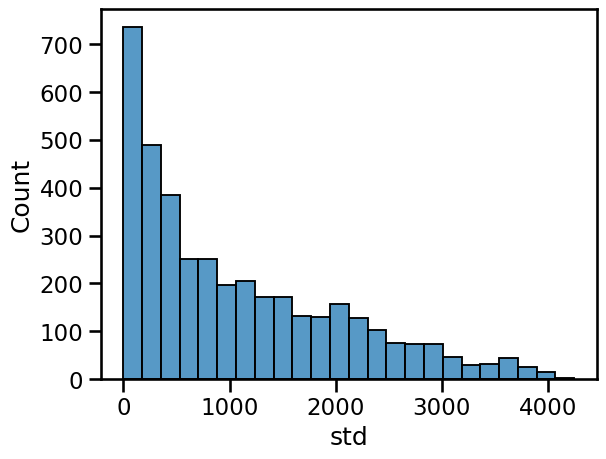

In [211]:
sns.histplot(over_n_reads_std["std"])

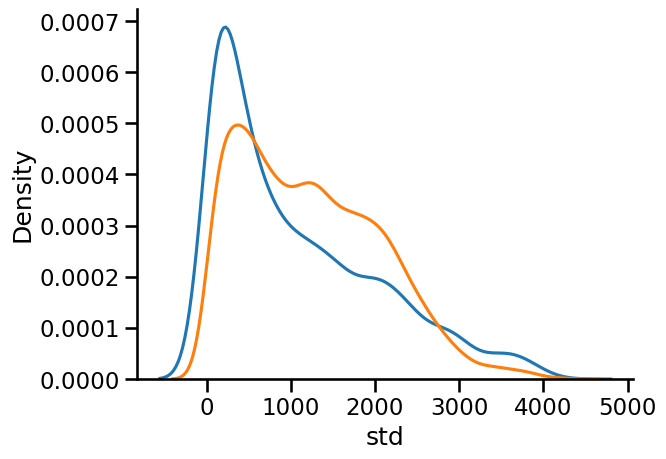

In [212]:
sns.kdeplot(over_n_reads_std["std"])
sns.kdeplot(data = ad_activity_with_both_errors, x = "bc_standard_dev", label = "Unweighted average")
sns.despine()